In [2]:
import keras
#from tensorflow.keras import Sequential
from keras.models import Sequential
#from keras.layers import Dense, Flatten, Conv3D, MaxPooling3D, Dropout
#from keras.utils import to_categorical

import tensorflow as tf
#from tensorflow.keras import Sequential
from keras.callbacks import Callback
# import h5py
import numpy as np
from keras import datasets, layers, models
import matplotlib.pyplot as plt
from matplotlib.image import imread
from numpy import genfromtxt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk

import pandas as pd

from matplotlib import pyplot as plt
import cv2

In [3]:
#data augmentation 
def split_and_reflect(image):
    width, height = image.shape[1], image.shape[0]

    # Split vertically
    left_half = image[:, :width // 2]
    right_half = image[:, width // 2:]
    top_half = image[:height // 2, :]
    bottom_half = image [height // 2: , :]

    # Reflect vertically
    left_half_reflect = np.fliplr(left_half)
    right_half_reflect = np.fliplr(right_half)
    top_half_reflect = np.flipud(top_half)
    top_half_reflect = np.rot90(top_half_reflect, 1)
    bottom_half_reflect = np.flipud(bottom_half)
    bottom_half_reflect = np.rot90(bottom_half_reflect, 1)

    return left_half, right_half, left_half_reflect, right_half_reflect, top_half_reflect, bottom_half_reflect
    

In [4]:
# Step 1: Read CSV file
csv_file_path = 'good.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'a_Good/'

# Initialize empty lists to store image arrays and additional data
good_input = []
good_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)

    # Append image array to input_data
    good_input.append(img_array)

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    good_output.append(additional_data)

# Convert the lists to NumPy arrays
good_x = np.array(good_input)
good_y = np.array(good_output)

# Verify the shapes of the input and output arrays
print("Good input shape:", good_x.shape)
print("Good Output data shape:", good_y.shape)

# Verify the shapes of the input and output arrays
print("Good input shape:", good_x.shape)
print("Good Output data shape:", good_y.shape)

Good input shape: (622, 224, 224, 3)
Good Output data shape: (622, 7)
Good input shape: (622, 224, 224, 3)
Good Output data shape: (622, 7)


In [5]:
#no sky bottom
csv_file_path = 'good.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'a_Good/'

# Initialize empty lists to store image arrays and additional data
good_input = []
good_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)
    left_half, right_half, left_half_reflect, right_half_reflect, top_half_reflect, bottom_half_reflect= split_and_reflect(img_array)
    lh_array = np.array(left_half)
    rh_array = np.array(right_half)
    lhr_array = np.array(left_half_reflect)
    rhr_array = np.array(right_half_reflect)
    #thr_array = np.array (top_half_reflect)
    #bhr_array = np.array (bottom_half_reflect)

    # Append image array to input_data
    #good_input.append(img_array)
    good_input.extend([lh_array, rh_array, lhr_array, rhr_array])#, thr_array, bhr_array])

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    #good_output.append(additional_data)
    good_output.extend([additional_data]*4)

# Convert the lists to NumPy arrays
good_x = np.array(good_input)
good_y = np.array(good_output)

# Verify the shapes of the input and output arrays
print("Good input shape:", good_x.shape)
print("Good Output data shape:", good_y.shape)

Good input shape: (2488, 224, 112, 3)
Good Output data shape: (2488, 7)


In [6]:
#sky bottom
csv_file_path = 'good.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'a_Good/'

# Initialize empty lists to store image arrays and additional data
good_input = []
good_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)
    left_half, right_half, left_half_reflect, right_half_reflect, top_half_reflect, bottom_half_reflect= split_and_reflect(img_array)
    lh_array = np.array(left_half)
    rh_array = np.array(right_half)
    lhr_array = np.array(left_half_reflect)
    rhr_array = np.array(right_half_reflect)
    thr_array = np.array (top_half_reflect)
    bhr_array = np.array (bottom_half_reflect)

    # Append image array to input_data
    #good_input.append(img_array)
    good_input.extend([lh_array, rh_array, lhr_array, rhr_array, thr_array, bhr_array])

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    #good_output.append(additional_data)
    good_output.extend([additional_data]*6)

# Convert the lists to NumPy arrays
good_x = np.array(good_input)
good_y = np.array(good_output)

# Verify the shapes of the input and output arrays
print("Good input shape:", good_x.shape)
print("Good Output data shape:", good_y.shape)

Good input shape: (3732, 224, 112, 3)
Good Output data shape: (3732, 7)


In [7]:
# Step 1: Read CSV file
#no sky bottom
csv_file_path = 'moderate.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'b_Moderate/'

# Initialize empty lists to store image arrays and additional data
moderate_input = []
moderate_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)
    left_half, right_half, left_half_reflect, right_half_reflect, top_half_reflect, bottom_half_reflect= split_and_reflect(img_array)
    lh_array = np.array(left_half)
    rh_array = np.array(right_half)
    lhr_array = np.array(left_half_reflect)
    rhr_array = np.array(right_half_reflect)
    #thr_array = np.array (top_half_reflect)
    #bhr_array = np.array (bottom_half_reflect)

    # Append image array to input_data
    #moderate_input.append(img_array)
    moderate_input.extend([lh_array, rh_array, lhr_array, rhr_array])#, thr_array, bhr_array])

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    moderate_output.extend([additional_data]*4)
    #moderate_output.append(additional_data)


# Convert the lists to NumPy arrays
moderate_x = np.array(moderate_input)
moderate_y = np.array(moderate_output)

# Verify the shapes of the input and output arrays
print("Moderate input shape:", moderate_x.shape)
print("Moderate Output data shape:", moderate_y.shape)

Moderate input shape: (3848, 224, 112, 3)
Moderate Output data shape: (3848, 7)


In [8]:
# Step 1: Read CSV file
#original
csv_file_path = 'moderate.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'b_Moderate/'

# Initialize empty lists to store image arrays and additional data
moderate_input = []
moderate_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)

    # Append image array to input_data
    moderate_input.append(img_array)

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    moderate_output.append(additional_data)

# Convert the lists to NumPy arrays
moderate_x = np.array(moderate_input)
moderate_y = np.array(moderate_output)

# Verify the shapes of the input and output arrays
print("Moderate input shape:", moderate_x.shape)
print("Moderate Output data shape:", moderate_y.shape)

Moderate input shape: (962, 224, 224, 3)
Moderate Output data shape: (962, 7)


In [9]:
# Step 1: Read CSV file
#sky bottom
csv_file_path = 'moderate.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'b_Moderate/'

# Initialize empty lists to store image arrays and additional data
moderate_input = []
moderate_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)
    left_half, right_half, left_half_reflect, right_half_reflect, top_half_reflect, bottom_half_reflect= split_and_reflect(img_array)
    lh_array = np.array(left_half)
    rh_array = np.array(right_half)
    lhr_array = np.array(left_half_reflect)
    rhr_array = np.array(right_half_reflect)
    thr_array = np.array (top_half_reflect)
    bhr_array = np.array (bottom_half_reflect)

    # Append image array to input_data
    #moderate_input.append(img_array)
    moderate_input.extend([lh_array, rh_array, lhr_array, rhr_array, thr_array, bhr_array])

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    moderate_output.extend([additional_data]*6)
    #moderate_output.append(additional_data)


# Convert the lists to NumPy arrays
moderate_x = np.array(moderate_input)
moderate_y = np.array(moderate_output)

# Verify the shapes of the input and output arrays
print("Moderate input shape:", moderate_x.shape)
print("Moderate Output data shape:", moderate_y.shape)

Moderate input shape: (5772, 224, 112, 3)
Moderate Output data shape: (5772, 7)


In [10]:
# Step 1: Read CSV file
#no sky
csv_file_path = 'unhealthy.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'c_Unhealthy_for_Sensitive_Groups/'

# Initialize empty lists to store image arrays and additional data
unhealthy_sen_input = []
unhealthy_sen_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)
    left_half, right_half, left_half_reflect, right_half_reflect, top_half_reflect, bottom_half_reflect= split_and_reflect(img_array)
    lh_array = np.array(left_half)
    rh_array = np.array(right_half)
    lhr_array = np.array(left_half_reflect)
    rhr_array = np.array(right_half_reflect)
    #thr_array = np.array (top_half_reflect)
    #bhr_array = np.array (bottom_half_reflect)

    # Append image array to input_data
    #unhealthy_sen_input.append(img_array)
    unhealthy_sen_input.extend([lh_array, rh_array, lhr_array, rhr_array])#, thr_array, bhr_array])

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    #unhealthy_sen_output.append(additional_data)
    unhealthy_sen_output.extend([additional_data]*4)

# Convert the lists to NumPy arrays
unhealthy_sen_x = np.array(unhealthy_sen_input)
unhealthy_sen_y = np.array(unhealthy_sen_output)

# Verify the shapes of the input and output arrays
print("Unhealthy Sensitive input shape:", unhealthy_sen_x.shape)
print("Unhealthy Sensitive Output data shape:", unhealthy_sen_y.shape)

Unhealthy Sensitive input shape: (1368, 224, 112, 3)
Unhealthy Sensitive Output data shape: (1368, 7)


In [11]:
# Step 1: Read CSV file
csv_file_path = 'unhealthy.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'c_Unhealthy_for_Sensitive_Groups/'

# Initialize empty lists to store image arrays and additional data
unhealthy_sen_input = []
unhealthy_sen_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)

    # Append image array to input_data
    unhealthy_sen_input.append(img_array)

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    unhealthy_sen_output.append(additional_data)

# Convert the lists to NumPy arrays
unhealthy_sen_x = np.array(unhealthy_sen_input)
unhealthy_sen_y = np.array(unhealthy_sen_output)

# Verify the shapes of the input and output arrays
print("Unhealthy Sensitive input shape:", unhealthy_sen_x.shape)
print("Unhealthy Sensitive Output data shape:", unhealthy_sen_y.shape)

Unhealthy Sensitive input shape: (342, 224, 224, 3)
Unhealthy Sensitive Output data shape: (342, 7)


In [12]:
# Step 1: Read CSV file
#sky
csv_file_path = 'unhealthy.csv'
csv_data = pd.read_csv(csv_file_path)

# Step 2: Process Images and Create Separate Arrays for Input and Output
image_folder_path = 'c_Unhealthy_for_Sensitive_Groups/'

# Initialize empty lists to store image arrays and additional data
unhealthy_sen_input = []
unhealthy_sen_output = []

for index, row in csv_data.iterrows():
    filename = row['Filename']
    image_path = image_folder_path + filename  # Adjust this according to your file structure
    img = Image.open(image_path)
    img_array = np.array(img)
    left_half, right_half, left_half_reflect, right_half_reflect, top_half_reflect, bottom_half_reflect= split_and_reflect(img_array)
    lh_array = np.array(left_half)
    rh_array = np.array(right_half)
    lhr_array = np.array(left_half_reflect)
    rhr_array = np.array(right_half_reflect)
    thr_array = np.array (top_half_reflect)
    bhr_array = np.array (bottom_half_reflect)

    # Append image array to input_data
    #unhealthy_sen_input.append(img_array)
    unhealthy_sen_input.extend([lh_array, rh_array, lhr_array, rhr_array, thr_array, bhr_array])

    # Append additional data to output_data
    additional_data = [row['AQI'], row['PM2.5'], row['PM10'], row['O3'], row['CO'], row['SO2'], row['NO2']]
    #unhealthy_sen_output.append(additional_data)
    unhealthy_sen_output.extend([additional_data]*6)

# Convert the lists to NumPy arrays
unhealthy_sen_x = np.array(unhealthy_sen_input)
unhealthy_sen_y = np.array(unhealthy_sen_output)

# Verify the shapes of the input and output arrays
print("Unhealthy Sensitive input shape:", unhealthy_sen_x.shape)
print("Unhealthy Sensitive Output data shape:", unhealthy_sen_y.shape)

Unhealthy Sensitive input shape: (2052, 224, 112, 3)
Unhealthy Sensitive Output data shape: (2052, 7)


In [13]:
x = np.concatenate((good_x, moderate_x, unhealthy_sen_x), axis=0)
print(x.shape)

y = np.concatenate((good_y, moderate_y, unhealthy_sen_y), axis=0)
print(y.shape)
# Assuming y_train is your original output data with shape (number of samples, 7)
scaler = MinMaxScaler()
y = scaler.fit_transform(y)

(11556, 224, 112, 3)
(11556, 7)


In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.40, random_state=42)

In [15]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(6933, 224, 112, 3)
(6933, 7)
(4623, 224, 112, 3)
(4623, 7)


In [16]:
y_train_2 = y_train[:, 1:3]
y_train_4 =y_train[:, 3:]
y_train_5 = np.insert( y_train_4, 0, y_train[:, 0], axis=1)
y_test_2 = y_test[:, 1:3]
y_test_4 = y_test[:, 3:]
y_test_5 = np.insert( y_test_4, 0, y_test[:, 0], axis=1)
print(y_train_2.shape)
print(y_train_5.shape)
print(y_test_2.shape)
print(y_test_5.shape)

(6933, 2)
(6933, 5)
(4623, 2)
(4623, 5)


In [17]:
# Re-scaling and typecasting to float
x_train, x_test = x_train / 255.0, x_test / 255.0
type(x_train[0][0][0][0])

numpy.float64

In [18]:
# NR_CLASSES = 10
VALIDATION_SIZE = 0.2
# TRAIN_SIZE = 1000
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
CHANNELS = 3
EPOCH = 5
TOTAL_INPUTS = IMAGE_WIDTH * IMAGE_HEIGHT * CHANNELS

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

# Define the multi-task CNN model
def build_multi_task_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3)) (inputs)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.MaxPooling2D((2, 2)) (x)
    x = layers.Conv2D(64, (3, 3)) (x)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.MaxPooling2D((2, 2)) (x)
    x = layers.Conv2D(64, (3, 3)) (x)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.Flatten() (x)
        
    #inputs = layers.Input(shape=input_shape)
    #x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    #x = layers.MaxPooling2D((2, 2))(x)
    #x = layers.Flatten()(x)
    
    # Separate fully connected layers for each task
    x_2_params = layers.Dense(128, activation= 'relu')(x)
    #x_2_params = layers.LeakyReLU (x_2_params)
    x_2_params = layers.Dense(64, activation = 'relu') (x_2_params)
    #x_2_params = layers.LeakyReLU (x_2_params)
    outputs_2_params = layers.Dense(2, activation='linear', name='output_2_params')(x_2_params)
    
    x_5_params = layers.Dense(128, activation = 'relu')(x)
    #x_5_params = layers.LeakyReLU (x_5_params)
    x_5_params = layers.Dense(64, activation = 'relu') (x_5_params)
    #x_5_params = layers.LeakyReLU (x_5_params)
    outputs_5_params = layers.Dense(5, activation='linear', name='output_5_params')(x_5_params)
    
    model = models.Model(inputs=inputs, outputs=[outputs_2_params, outputs_5_params])
    return model

input_shape = (224, 112, 3)  #changes by me from (224, 224, 3) to (224, 112, 3)

model = build_multi_task_cnn(input_shape)
#model.fit(x_train, {'output_2_params': y_train_2}, epochs=20, validation_split=0.2)

# Define losses and loss weights
losses = {
    'output_2_params': losses.MeanAbsoluteError(),
    'output_5_params': losses.MeanAbsoluteError()
}
loss_weights = {
    'output_2_params': 0.5,  # Adjust these weights based on importance
    'output_5_params': 0.5
}

# Compile the model
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss=losses,
              loss_weights=loss_weights,
              metrics={'output_2_params': 'mse', 'output_5_params': 'mse'})

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 112,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 222, 110,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 222, 110,  │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 111, 55,   │          0 │ leaky_re_lu[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 53,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 109, 53,   │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 54, 26,    │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 52, 24,    │     36,928 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 52, 24,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 79872)     │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │ 10,223,744 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │ 10,223,744 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_2_params     │ (None, 2)         │        130 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_5_params     │ (None, 5)         │        325 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,520,775 (78.28 MB)

 Trainable params: 20,520,775 (78.28 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(x_train, {'output_2_params': y_train_2, 'output_5_params': y_train_5}, epochs=5)

Epoch 1/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 82s 348ms/step - loss: 0.4012 - output_2_params_loss: 0.4202 - output_2_params_mse: 1.7538 - output_5_params_loss: 0.3822 - output_5_params_mse: 1.0587
Epoch 2/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 72s 330ms/step - loss: 0.1443 - output_2_params_loss: 0.1245 - output_2_params_mse: 0.0301 - output_5_params_loss: 0.1642 - output_5_params_mse: 0.0492
Epoch 3/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 71s 327ms/step - loss: 0.1314 - output_2_params_loss: 0.1120 - output_2_params_mse: 0.0263 - output_5_params_loss: 0.1508 - output_5_params_mse: 0.0435
Epoch 4/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 84s 387ms/step - loss: 0.1238 - output_2_params_loss: 0.1057 - output_2_params_mse: 0.0234 - output_5_params_loss: 0.1419 - output_5_params_mse: 0.0387
Epoch 5/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 100s 458ms/step - loss: 0.1114 - output_2_params_loss: 0.0948 - output_2_params_mse: 0.0198 - output_5_params_loss: 0.1279 - output_5_params_mse: 0.0331


In [21]:
results = model.evaluate(x_test, {'output_2_params': y_test_2, 'output_5_params': y_test_5})
print(results)

145/145 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - loss: 0.1188 - output_2_params_loss: 0.1022 - output_2_params_mse: 0.0237 - output_5_params_loss: 0.1354 - output_5_params_mse: 0.0373
[0.1196398213505745, 0.1025351956486702, 0.13672049343585968, 0.023914359509944916, 0.03759567067027092]


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

# Define the multi-task CNN model
def build_multi_task_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3)) (inputs)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.MaxPooling2D((2, 2)) (x)
    x = layers.Conv2D(64, (3, 3)) (x)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.MaxPooling2D((2, 2)) (x)
    x = layers.Conv2D(64, (3, 3)) (x)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.Flatten() (x)
        
    #inputs = layers.Input(shape=input_shape)
    #x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    #x = layers.MaxPooling2D((2, 2))(x)
    #x = layers.Flatten()(x)
    
    # Separate fully connected layers for each task
    x_2_params = layers.Dense(128, activation= 'relu')(x)
    #x_2_params = layers.LeakyReLU (x_2_params)
    x_2_params = layers.Dense(64, activation = 'relu') (x_2_params)
    #x_2_params = layers.LeakyReLU (x_2_params)
    outputs_2_params = layers.Dense(2, activation='linear', name='output_2_params')(x_2_params)
    
    x_5_params = layers.Dense(128, activation = 'relu')(x)
    #x_5_params = layers.LeakyReLU (x_5_params)
    x_5_params = layers.Dense(64, activation = 'relu') (x_5_params)
    #x_5_params = layers.LeakyReLU (x_5_params)
    outputs_5_params = layers.Dense(5, activation='linear', name='output_5_params')(x_5_params)
    
    model = models.Model(inputs=inputs, outputs=[outputs_2_params, outputs_5_params])
    return model

input_shape = (224, 112, 3)

model_nosky = build_multi_task_cnn(input_shape)
#model.fit(x_train, {'output_2_params': y_train_2}, epochs=20, validation_split=0.2)

# Define losses and loss weights
losses = {
    'output_2_params': losses.MeanAbsoluteError(),
    'output_5_params': losses.MeanAbsoluteError()
}
loss_weights = {
    'output_2_params': 0.5,  # Adjust these weights based on importance
    'output_5_params': 0.5
}

# Compile the model
model_nosky.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss=losses,
              loss_weights=loss_weights,
              metrics={'output_2_params': 'mse', 'output_5_params': 'mse'})

model_nosky.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 112,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 222, 110,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 222, 110,  │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 111, 55,   │          0 │ leaky_re_lu_3[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 109, 53,   │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 109, 53,   │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 54, 26,    │          0 │ leaky_re_lu_4[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 52, 24,    │     36,928 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 52, 24,    │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 79872)     │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │ 10,223,744 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │ 10,223,744 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_2_params     │ (None, 2)         │        130 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_5_params     │ (None, 5)         │        325 │ dense_7[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,520,775 (78.28 MB)

 Trainable params: 20,520,775 (78.28 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_nosky = model_nosky.fit(x_train, {'output_2_params': y_train_2, 'output_5_params': y_train_5}, epochs=5)

Epoch 1/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 108s 453ms/step - loss: 0.3661 - output_2_params_loss: 0.4138 - output_2_params_mse: 1.7626 - output_5_params_loss: 0.3183 - output_5_params_mse: 0.6843
Epoch 2/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 98s 450ms/step - loss: 0.1389 - output_2_params_loss: 0.1202 - output_2_params_mse: 0.0285 - output_5_params_loss: 0.1576 - output_5_params_mse: 0.0464
Epoch 3/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 97s 447ms/step - loss: 0.1307 - output_2_params_loss: 0.1132 - output_2_params_mse: 0.0257 - output_5_params_loss: 0.1482 - output_5_params_mse: 0.0422
Epoch 4/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 97s 446ms/step - loss: 0.1143 - output_2_params_loss: 0.0983 - output_2_params_mse: 0.0220 - output_5_params_loss: 0.1303 - output_5_params_mse: 0.0346
Epoch 5/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 97s 446ms/step - loss: 0.1067 - output_2_params_loss: 0.0912 - output_2_params_mse: 0.0188 - output_5_params_loss: 0.1223 - output_5_params_mse: 0.0307


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

# Define the multi-task CNN model
def build_multi_task_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3)) (inputs)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.MaxPooling2D((2, 2)) (x)
    x = layers.Conv2D(64, (3, 3)) (x)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.MaxPooling2D((2, 2)) (x)
    x = layers.Conv2D(64, (3, 3)) (x)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.Flatten() (x)
        
    #inputs = layers.Input(shape=input_shape)
    #x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    #x = layers.MaxPooling2D((2, 2))(x)
    #x = layers.Flatten()(x)
    
    # Separate fully connected layers for each task
    x_2_params = layers.Dense(128, activation= 'relu')(x)
    #x_2_params = layers.LeakyReLU (x_2_params)
    x_2_params = layers.Dense(64, activation = 'relu') (x_2_params)
    #x_2_params = layers.LeakyReLU (x_2_params)
    outputs_2_params = layers.Dense(2, activation='linear', name='output_2_params')(x_2_params)
    
    x_5_params = layers.Dense(128, activation = 'relu')(x)
    #x_5_params = layers.LeakyReLU (x_5_params)
    x_5_params = layers.Dense(64, activation = 'relu') (x_5_params)
    #x_5_params = layers.LeakyReLU (x_5_params)
    outputs_5_params = layers.Dense(5, activation='linear', name='output_5_params')(x_5_params)
    
    model = models.Model(inputs=inputs, outputs=[outputs_2_params, outputs_5_params])
    return model

input_shape = (224, 112, 3)

model_sky = build_multi_task_cnn(input_shape)
#model.fit(x_train, {'output_2_params': y_train_2}, epochs=20, validation_split=0.2)

# Define losses and loss weights
losses = {
    'output_2_params': losses.MeanAbsoluteError(),
    'output_5_params': losses.MeanAbsoluteError()
}
loss_weights = {
    'output_2_params': 0.5,  # Adjust these weights based on importance
    'output_5_params': 0.5
}

# Compile the model
model_sky.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss=losses,
              loss_weights=loss_weights,
              metrics={'output_2_params': 'mse', 'output_5_params': 'mse'})

model_sky.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 112,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 222, 110,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 222, 110,  │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 111, 55,   │          0 │ leaky_re_lu_6[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 109, 53,   │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 109, 53,   │          0 │ conv2d_7[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 54, 26,    │          0 │ leaky_re_lu_7[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 52, 24,    │     36,928 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 52, 24,    │          0 │ conv2d_8[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 79872)     │          0 │ leaky_re_lu_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │ 10,223,744 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │ 10,223,744 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_2_params     │ (None, 2)         │        130 │ dense_9[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_5_params     │ (None, 5)         │        325 │ dense_11[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,520,775 (78.28 MB)

 Trainable params: 20,520,775 (78.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_sky = model_sky.fit(x_train, {'output_2_params': y_train_2, 'output_5_params': y_train_5}, epochs=5)

Epoch 1/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 104s 448ms/step - loss: 0.2551 - output_2_params_loss: 0.2597 - output_2_params_mse: 0.3930 - output_5_params_loss: 0.2506 - output_5_params_mse: 0.1795
Epoch 2/5
 95/217 ━━━━━━━━━━━━━━━━━━━━ 45:48 23s/step - loss: 0.1381 - output_2_params_loss: 0.1168 - output_2_params_mse: 0.0268 - output_5_params_loss: 0.1594 - output_5_params_mse: 0.0465

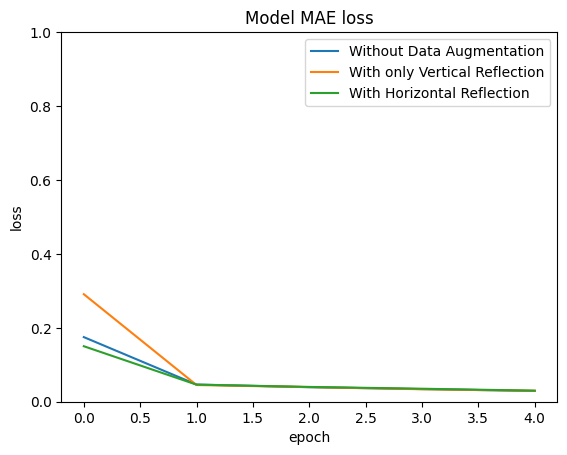

In [ ]:
plt.plot(history.history['output_5_params_mse'], label= 'Without Data Augmentation')
plt.plot(history_nosky.history['output_5_params_mse'], label= 'With only Vertical Reflection')
plt.plot(history_sky.history['output_5_params_mse'], label= 'With Horizontal Reflection')
#plt.plot(history.history['output_5_params_loss'])
#plt.plot(history.history['output_2_params_mse'])
#plt.plot(history.history['output_5_params_mse'])
#plt.plot(history.history['val_loss'])
plt.title('Model MAE loss')
plt.ylabel('loss')
plt.ylim(0.0, 1)
plt.xlabel('epoch')
plt.legend()
#plt.legend(['output_2_params_loss', 'output_5_params_loss', 'output_2_params_mse', 'output_5_params_mse'], loc='upper right')
#plt.savefig('Bengaluru_5params_mae_trimmed.jpg')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import numpy as np

def build_multi_task_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3)) (inputs)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.MaxPooling2D((2, 2)) (x)
    x = layers.Conv2D(64, (3, 3)) (x)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.MaxPooling2D((2, 2)) (x)
    x = layers.Conv2D(64, (3, 3)) (x)
    x = layers.LeakyReLU(0.3) (x)
    x = layers.Flatten() (x)
    print(x.shape)
    x_2_params = layers.Dense(128, activation= 'relu')(x)
    x_2_params = layers.Dense(64, activation = 'relu') (x_2_params)
    outputs_2_params = layers.Dense(2, activation='linear', name='output_2_params')(x_2_params)
    model = models.Model(inputs=inputs, outputs=outputs_2_params)
    return model

input_shape = (224, 112, 3)   #changes my me from (224, 224, 3) to (224, 112, 3)
model = build_multi_task_cnn(input_shape)
losses = {
    'output_2_params': losses.MeanAbsoluteError()
}

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss=losses,
              #loss_weights=loss_weights,
              metrics={'output_2_params': 'mse'})

model.summary()

# Convert data to float32 before training
y_train_2 = y_train_2.astype(np.float32)

# For single-output model, pass y_train_2 directly, not as dictionary
model.fit(x_train, y_train_2, epochs=5, validation_split=0.2)

#extended_features = np.concatenate([X_original, pred_o3, pred_so2, pred_co, pred_no2], axis=1)

(None, 79872)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 222, 110, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 222, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 55, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 53, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 109, 53, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 52, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 79872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    10,223,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_2_params (Dense)         │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,288,450 (39.25 MB)

 Trainable params: 10,288,450 (39.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 48s 272ms/step - loss: 0.6253 - mse: 4.7286 - val_loss: 0.1278 - val_mse: 0.0284
Epoch 2/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 48s 272ms/step - loss: 0.6253 - mse: 4.7286 - val_loss: 0.1278 - val_mse: 0.0284
Epoch 2/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 45s 256ms/step - loss: 0.1329 - mse: 0.0335 - val_loss: 0.1218 - val_mse: 0.0309
Epoch 3/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 45s 256ms/step - loss: 0.1329 - mse: 0.0335 - val_loss: 0.1218 - val_mse: 0.0309
Epoch 3/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 44s 255ms/step - loss: 0.1204 - mse: 0.0304 - val_loss: 0.1198 - val_mse: 0.0263
Epoch 4/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 44s 255ms/step - loss: 0.1204 - mse: 0.0304 - val_loss: 0.1198 - val_mse: 0.0263
Epoch 4/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 44s 251ms/step - loss: 0.1214 - mse: 0.0298 - val_loss: 0.1275 - val_mse: 0.0336
Epoch 5/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 44s 251ms/step - loss: 0.1214 - mse: 0.0298 - val_loss: 0.1275 - val_mse: 0.0336
Epoch 5/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:
y_pred_2 = model.predict(x_test)
y_pred_2.shape

145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step


(4623, 2)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import numpy as np

def build_pred_cnn (input_shape):
    inputs = layers.Input(shape= input_shape)
    p = layers.Dense (64, activation= 'relu') (inputs)
    p = layers.Dense (32, activation= 'relu') (p)
    outputs_5_params = layers.Dense (5, activation = 'linear', name= 'outputs_5_params') (p)
    model = models.Model (inputs= inputs, outputs= outputs_5_params)
    return model

input_shape = (2,)
model = build_pred_cnn (input_shape)

losses = {
    'outputs_5_params': losses.MeanAbsoluteError()
}

loss_weights = {
    'outputs_5_params': 1.0
}

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss=losses,
              #loss_weights=loss_weights,
              metrics={'outputs_5_params': 'mse'})

model.summary()

# Fix: Correct argument order and use direct target format for single-output model
# Convert target to float32 to avoid type errors
y_train_5_float = y_train_5.astype(np.float32)
model.fit(y_pred_2, y_train_5_float, epochs=50, validation_split=0.2)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs_5_params (Dense)        │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,437 (9.52 KB)

 Trainable params: 2,437 (9.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3080 - mse: 0.1481 - val_loss: 0.1858 - val_mse: 0.0585
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3080 - mse: 0.1481 - val_loss: 0.1858 - val_mse: 0.0585
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1847 - mse: 0.0584 - val_loss: 0.1853 - val_mse: 0.0578
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1847 - mse: 0.0584 - val_loss: 0.1853 - val_mse: 0.0578
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1835 - mse: 0.0574 - val_loss: 0.1851 - val_mse: 0.0581
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1835 - mse: 0.0574 - val_loss: 0.1851 - val_mse: 0.0581
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1855 - mse: 0.0587 - val_loss: 0.1850 - val_mse: 0.0588
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1855 - mse: 0.0587 - val_loss: 0.1850 - val_mse: 0.0588
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [ ]:
pip install dash dash-bootstrap-components

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
import os
import numpy as np

# Sample data: Symptoms and their associated pollutants
symptom_pollutant_map = {
    "Coughing" :  ["PM2.5", "PM10", "NO2", "O3", "SO2"], 
    "Headache" : ["CO","PM2.5", "PM10"],
    "Breathing problems": ["PM2.5", "CO", "SO2"],
    "Poor Visibility" : ["PM2.5", "PM10"],
    "Irritation of Nose/Throat" : ["SO2"],
    "Skin problem" : ["NO2", "PM2.5", "PM10", "O3"],
    "Eye Itching" : ["CO", "NO2",  "PM2.5", "PM10", "O3"],
}

# Directory to save the uploaded images
save_directory = "./uploaded_images"
os.makedirs(save_directory, exist_ok=True)

class HealthDashboard(tk.Tk):
    def __init__(self, model):
        super().__init__()

        self.title("HealthCamCNN")
        self.geometry("800x600")

        # Set background color
        self.configure(bg="#f0f4c3")  

        # Variables to hold user info
        self.user_name = tk.StringVar()
        self.user_age = tk.StringVar()
        self.user_gender = tk.StringVar()

        # Variables to hold selected symptoms and uploaded image
        self.selected_symptoms = []
        self.image_path = None
        self.model = model  # Use the model passed during initialization
        
        # Initialize photo variable to prevent garbage collection
        self.photo = None

        # Show the intro page first
        self.show_intro_page()

    def show_intro_page(self):
        # Clear the window
        for widget in self.winfo_children():
            widget.destroy()

        # Font configuration
        title_font = ("Helvetica", 16, "bold")
        label_font = ("Helvetica", 12)
        button_font = ("Helvetica", 12, "bold")

        # Introductory message
        intro_label = tk.Label(self, text="Welcome to our Health Recommendation System!", font=title_font, bg="#f0f4c3", fg="#37474f")
        intro_label.pack(pady=20)

        # Name entry
        name_label = tk.Label(self, text="Enter your name:", font=label_font, bg="#f0f4c3", fg="#37474f")
        name_label.pack(pady=5)
        name_entry = tk.Entry(self, textvariable=self.user_name, font=label_font)
        name_entry.pack(pady=5)

        # Age entry
        age_label = tk.Label(self, text="Enter your age:", font=label_font, bg="#f0f4c3", fg="#37474f")
        age_label.pack(pady=5)
        age_entry = tk.Entry(self, textvariable=self.user_age, font=label_font)
        age_entry.pack(pady=5)

        # Gender entry
        gender_label = tk.Label(self, text="Select your gender:", font=label_font, bg="#f0f4c3", fg="#37474f")
        gender_label.pack(pady=5)

        gender_options = ["Male", "Female", "Other"]
        gender_menu = tk.OptionMenu(self, self.user_gender, *gender_options)
        gender_menu.pack(pady=5)

        # Continue button to proceed to the main dashboard
        continue_button = tk.Button(self, text="Continue", command=self.show_main_dashboard, font=button_font, bg="#8bc34a", fg="white")
        continue_button.pack(pady=20)

    def show_main_dashboard(self):
        # Clear the window
        for widget in self.winfo_children():
            widget.destroy()

        # Create the main dashboard widgets
        self.create_widgets()

    def create_widgets(self):
        # Font configuration
        title_font = ("Helvetica", 16, "bold")
        label_font = ("Helvetica", 12)
        button_font = ("Helvetica", 12, "bold")
        result_font = ("Helvetica", 14)

        # Main container for the left and right frames
        main_frame = tk.Frame(self, bg="#f0f4c3")
        main_frame.pack(expand=True, fill="both", padx=20, pady=20)

        # Left frame for image-related components
        left_frame = tk.Frame(main_frame, bg="#f0f4c3")
        left_frame.pack(side="left", expand=True, fill="both")

        # Right frame for results and symptom selection
        right_frame = tk.Frame(main_frame, bg="#f0f4c3")
        right_frame.pack(side="right", expand=True, fill="both")

        # Label for symptoms selection
        symptom_label = tk.Label(right_frame, text="Select Your Symptoms:", font=title_font, bg="#f0f4c3", fg="#37474f")
        symptom_label.pack(pady=10)

        # Checkbox for each symptom
        self.symptom_vars = {}
        for symptom in symptom_pollutant_map.keys():
            var = tk.BooleanVar()
            cb = tk.Checkbutton(right_frame, text=symptom, variable=var, font=label_font, bg="#f0f4c3", fg="#37474f")
            cb.pack(anchor='w')
            self.symptom_vars[symptom] = var

        # Button to upload image
        upload_button = tk.Button(left_frame, text="Upload Image", command=self.upload_image, font=button_font, bg="#8bc34a", fg="white")
        upload_button.pack(pady=10)

        # Canvas to display image
        self.image_canvas = tk.Canvas(left_frame, width=400, height=300, bg="gray")
        self.image_canvas.pack(pady=10)

        # Button to show results
        result_button = tk.Button(right_frame, text="Show Results", command=self.show_results, font=button_font, bg="#8bc34a", fg="white")
        result_button.pack(pady=10)

        # Labels to display results
        self.pollutant_label = tk.Label(right_frame, text="", font=result_font, bg="#f0f4c3", fg="#37474f", wraplength=300, justify='left')
        self.pollutant_label.pack(pady=10)

    def upload_image(self):
        # Open a file dialog to select an image
        file_path = filedialog.askopenfilename(
            filetypes=[("Image Files", "*.png;*.jpg;*.jpeg")]
        )
        if file_path:
            try:
                # Save the image to the desired location
                self.image_path = os.path.join(save_directory, os.path.basename(file_path))
                image = Image.open(file_path)
                image.save(self.image_path)

                # Display the image
                self.display_image(self.image_path)
            except Exception as e:
                messagebox.showerror("Error", f"Failed to load image: {str(e)}")

    def display_image(self, path):
        try:
            # Clear the canvas first
            self.image_canvas.delete("all")
            
            # Open and display the image using Pillow
            image = Image.open(path)
            image.thumbnail((400, 300))  # Resize to fit canvas
            
            # Create PhotoImage and keep a reference to prevent garbage collection
            self.photo = ImageTk.PhotoImage(image)
            
            # Create image on canvas
            self.image_canvas.create_image(200, 150, image=self.photo)
            
        except Exception as e:
            print(f"Error displaying image: {str(e)}")
            # If there's an error, show a text message instead
            self.image_canvas.delete("all")
            self.image_canvas.create_text(200, 150, text="Image loaded\n(Display error)", 
                                        fill="white", font=("Arial", 12))

    def show_results(self):
        # Update selected symptoms
        self.selected_symptoms = [
            symptom for symptom, var in self.symptom_vars.items() if var.get()
        ]

        if not self.selected_symptoms:
            messagebox.showinfo("Results", "No symptoms selected")
            return

        if not self.image_path:
            messagebox.showinfo("Results", "No image uploaded")
            return

        try:
            # Load the image and prepare it for prediction
            img = self.load_image_for_prediction(self.image_path)

            # Predict pollutant values using the neural network
            y_pred_2, y_pred_5 = self.model.predict(img)
            first_column_test = y_pred_5[:, 0:1]
            # Step 2: Concatenate first_column_test with y_test_2 to get the first three columns of y_test
            y_pred_first_three = np.concatenate((first_column_test, y_pred_2), axis=1)
            # Step 3: Extract the remaining columns from y_test_5 (excluding the first column)
            remaining_columns_pred = y_pred_5[:, 1:]
            # Step 4: Concatenate y_test_first_three with remaining_columns_test to reconstruct y_test
            y_pred_reconstructed = np.concatenate((y_pred_first_three, remaining_columns_pred), axis=1)
            y_pred = scaler.inverse_transform(y_pred_reconstructed)
            y_pred_2 = y_pred[:, 1:3]
            y_pred_4 =y_pred[:, 3:]
            y_pred_5 = np.insert( y_pred_4, 0, y_pred[:, 0], axis=1)

            # Display predicted values based on selected symptoms
            pollutant_output = "Responsible Pollutants:\n"

            for symptom in self.selected_symptoms:
                pollutants = symptom_pollutant_map[symptom]
                pollutant_values = []

                for pollutant in pollutants:
                    if pollutant == "PM2.5":
                        pollutant_values.append(f"PM2.5: {y_pred_2[0][0]:.2f}")
                    elif pollutant == "PM10":
                        pollutant_values.append(f"PM10: {y_pred_2[0][1]:.2f}")
                    elif pollutant == "AQI":
                        pollutant_values.append(f"AQI: {y_pred_5[0][0]:.2f}")
                    elif pollutant == "O3":
                        pollutant_values.append(f"O3: {y_pred_5[0][1]:.2f}")
                    elif pollutant == "CO":
                        pollutant_values.append(f"CO: {y_pred_5[0][2]:.2f}")
                    elif pollutant == "SO2":
                        pollutant_values.append(f"SO2: {y_pred_5[0][3]:.2f}")
                    elif pollutant == "NO2":
                        pollutant_values.append(f"NO2: {y_pred_5[0][4]:.2f}")

                pollutant_output += f"{symptom} - {', '.join(pollutant_values)}\n"

            self.pollutant_label.config(text=pollutant_output)
            
        except Exception as e:
            messagebox.showerror("Prediction Error", f"Failed to make predictions: {str(e)}")

    def load_image_for_prediction(self, image_path):
        # Load and preprocess the image for model input
        image = Image.open(image_path)
        # Fixed: PIL resize takes (width, height), so for model input (224, 112, 3) we need (112, 224)
        # Model expects: height=224, width=112, channels=3
        image = image.resize((112, 224))  # PIL format: (width, height) = (112, 224)
        image = np.array(image) / 255.0  # Normalize the image
        image = np.expand_dims(image, axis=0)  # Add batch dimension
        return image
    
    def on_closing(self):
        # Clean up resources when closing
        if hasattr(self, 'photo'):
            self.photo = None
        self.destroy()

# Close any existing app instances
try:
    if 'app' in globals() and app is not None:
        app.destroy()
except:
    pass

# Create new app instance
if __name__ == "__main__":
    app = HealthDashboard(model_sky)
    app.protocol("WM_DELETE_WINDOW", app.on_closing)
    app.mainloop()

NameError: name 'model_sky' is not defined